# Notebook summary of work 

In [1]:
# parent_folder_path = "/Users/haleyoro/Desktop/" # work on library computer
parent_folder_path = "/Users/Haley/Desktop/" # work on local computer


In [2]:
!pip3 install pyabf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyabf
import os
from waveforms_helpers2 import *
import pickle


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


Looking at the waveforms (from `Plotting` folder)

Annotations sheet --`App Script`--> unformatted csv files 

unformatted csv files --`process_excel`--> formatted csv files 

## `annotations_loader` : Make `sheets` dict with 38 dataframes of all processed .csvs

Load the cell types data frame to include info when reading .csv sheets

In [3]:
cell_types_df = pd.read_csv(parent_folder_path+"murray-neuroscience-lab/Cleaned, updated files from Spring/summary_spikes.csv")

cell_types_df.reset_index(drop=True,inplace=True)
sheets_types = cell_types_df["Cell"].unique().tolist()
print("Number of labeled sheets:",len(sheets_types))
cell_types_df

Number of labeled sheets: 25


,Cell,Motoneuron,Cell Type,Input Resistance,mean,median,min,max,total_spikes
0,2012_08_01_cell1,Low Rin Secondary,vSMN,287.00,24.97,24.52,18.47,38.55,41
1,2012_08_01_cell3,primary,MiP,49.99,42.55,42.84,29.46,52.69,65
2,2012_08_07,Low Rin Secondary,vSMN,219.00,29.31,31.48,10.54,38.93,67
3,2012_08_31_cell1,primary,MiP,45.33,39.28,38.40,26.93,52.55,64
4,2012_08_31_cell2,primary,vRoP,44.77,38.21,39.15,24.64,48.71,69
5,2012_08_31_cell3,primary,MiP,46.67,42.15,41.53,33.76,54.32,20
6,2012_08_31_cell4,Low Rin Secondary,dSMN,242.57,41.09,36.93,31.41,53.50,17
7,2012_10_04_cell2,Low Rin Secondary,dSMN,340.01,37.01,38.27,24.81,52.97,83
8,2012_12_03_cell1,High Rin Secondary,iSMN,830.00,28.02,26.69,19.99,51.63,465
9,2012_12_04_cell1,High Rin Secondary,vSMN,393.00,34.24,32.01,25.84,73.10,100


Create a dictionary looping through sheet names to load each sheet annotation as a data frame 
(.csv files were re-formatted using functions in `process_excel`, looping through the downloaded excel sheets from the annotations sheet in google drive. excel sheets were downloaded as .csvs using App Script code)

Keys are names of sheets

In [4]:
cell_types_df = pd.read_csv(parent_folder_path+"murray-neuroscience-lab/Cleaned, updated files from Spring/summary_spikes.csv")

cell_types_df.reset_index(drop=True,inplace=True)
sheets_types = cell_types_df["Cell"].unique().tolist()
sheet_names = cell_types_df.iloc[:,0].values
def make_sheets_dict(sheet_names,parent_folder_path):
    sheets = {}

    for sheet in sheet_names:
        file_path = parent_folder_path+"murray-neuroscience-lab/New processed excels/"+sheet+".csv"
        df = pd.read_csv(file_path)
        df[["Trace name","Tags","Type"]] = df[["Trace name","Tags","Type"]].astype("string")
        types = cell_types_df[cell_types_df["Cell"]==sheet]
        df.loc[:,"Median Spiking"] = types.iloc[0]["median"]
        df.loc[:,"Mean Spiking"] = types.iloc[0]["mean"]
        sheets[sheet] = df

    return sheets
sheets = make_sheets_dict(sheet_names,parent_folder_path)
sheets.keys()

dict_keys(['2012_08_01_cell1', '2012_08_01_cell3', '2012_08_07', '2012_08_31_cell1', '2012_08_31_cell2', '2012_08_31_cell3', '2012_08_31_cell4', '2012_10_04_cell2', '2012_12_03_cell1', '2012_12_04_cell1', '2012_12_05_cell1', '2012_12_05_cell3', '2012_12_05_cell4', '2012_12_06_cell1', '2012_12_06_cell4', '2013_03_20_cell1', '2013_03_21_cell1', '2013_03_21_cell3', '2013_03_21_cell4', '2013_03_21_cell5', '2013_03_22_cell1', '2013_03_22_cell2', '2013_03_22_cell4', '2013_03_22_cell5', '2013_03_22_cell6'])

Using one sheet name to access the formatted dataframe of the annotations, includes cell type and resistance

## `binwaves_` : make abfs dict to store .abf files for each of the 38 sheets

make `abfs` dict: contains the abf file of each trace in the annotation df sheet

need abfs[trace] and sheets[sheet[sheet["Trace name"]==Trace]]. test with one:

use loops in annotations loader to make mega dict

In [5]:
parent_folder_path_ABFS ="/Users/Haley/Desktop/ABF files annotated"
abfs_names = pd.read_csv(parent_folder_path+"murray-neuroscience-lab/Cleaned, updated files from Spring/all_trace_names.csv",header = None)
abfs_names = abfs_names.iloc[:,0].to_numpy()
abfs_names

array(['2012_04_25_0004', '2012_04_25_0005', '2012_04_25_0006', ...,
       '2013_03_22_0062', '2013_03_22_0063', '2012_10_04_0014'],
      shape=(242,), dtype=object)

2012_03_21_0027.abf not in drive folder

In [6]:
sheets_abfs = add_abfs(sheets,abfs_names,parent_folder_path_ABFS)
sheets_abfs.keys()

dict_keys(['2012_08_01_cell1', '2012_08_01_cell3', '2012_08_07', '2012_08_31_cell1', '2012_08_31_cell2', '2012_08_31_cell3', '2012_08_31_cell4', '2012_10_04_cell2', '2012_12_03_cell1', '2012_12_04_cell1', '2012_12_05_cell1', '2012_12_05_cell3', '2012_12_05_cell4', '2012_12_06_cell1', '2012_12_06_cell4', '2013_03_20_cell1', '2013_03_21_cell1', '2013_03_21_cell3', '2013_03_21_cell4', '2013_03_21_cell5', '2013_03_22_cell1', '2013_03_22_cell2', '2013_03_22_cell4', '2013_03_22_cell5', '2013_03_22_cell6'])

`sheets` is now a dictionary with `annotations` dataframe and `abfs` dict.
sheet names are still the keys

In [7]:
sheets_abfs['2012_08_01_cell1']

{'annotations':           Trace name  ID  On time     Freq               Tags  \
 0    2012_08_01_0009   1  2304.81      NaN  bout start; shock   
 1    2012_08_01_0009   2  2332.90  35.5999               <NA>   
 2    2012_08_01_0009   3  2353.79  47.8698               <NA>   
 3    2012_08_01_0009   4  2384.38  32.6904               <NA>   
 4    2012_08_01_0009   5  2422.12  26.4971               <NA>   
 ..               ...  ..      ...      ...                ...   
 607  2012_08_01_0003  21  6448.56  16.2575               <NA>   
 608  2012_08_01_0003  22  8173.00   0.5799               <NA>   
 609  2012_08_01_0003  23  8209.73  27.2257               <NA>   
 610  2012_08_01_0003  24  8381.96   5.8062               <NA>   
 611  2012_08_01_0003  25  8766.29   2.6019               <NA>   
 
                         Type  Seconds  Median Spiking  Mean Spiking  
 0                 Inhibitory  2.30481           24.52         24.97  
 1                 Inhibitory  2.33290           

Check to see if all abfs successfully loaded

In [8]:
abf_names = []
abf_annotations = []

for sheet in sheets.keys():
    # print(f"\nProcessing sheet: {sheet}")

    try:
        traces_abfs = sorted(sheets_abfs[sheet]['abfs'].keys())
        # print(f"  Found ABF traces: {traces_abfs}")
        abf_names.extend(traces_abfs)
    except KeyError as e:
        print(f"  Missing 'abfs' for sheet {sheet}: {e}")
    
    try:
        annotations = sheets_abfs[sheet]["annotations"]
        # print(f"  Annotations columns: {annotations.columns}")
        traces_annotated = sorted(annotations["Trace name"].unique().tolist())
        # print(f"  Found annotations: {traces_annotated}")
        abf_annotations.extend(traces_annotated)
    except KeyError as e:
        print(f"  Missing 'annotations' or 'Trace name' column: {e}")
    except AttributeError as e:
        print(f"  'annotations' is not a DataFrame? {e}")


In [9]:
abf_names = []
abf_annotations = []
for sheet in sheets.keys():
    print(sheet)
    traces_abfs=sorted(sheets_abfs[sheet]['abfs'].keys())
    abf_names.extend(traces_abfs)
    annotations = sheets_abfs[sheet]["annotations"]
    traces_annotated = sorted(annotations["Trace name"].unique().tolist())
    abf_annotations.extend(traces_annotated) 



2012_08_01_cell1
2012_08_01_cell3
2012_08_07
2012_08_31_cell1
2012_08_31_cell2
2012_08_31_cell3
2012_08_31_cell4
2012_10_04_cell2
2012_12_03_cell1
2012_12_04_cell1
2012_12_05_cell1
2012_12_05_cell3
2012_12_05_cell4
2012_12_06_cell1
2012_12_06_cell4
2013_03_20_cell1
2013_03_21_cell1
2013_03_21_cell3
2013_03_21_cell4
2013_03_21_cell5
2013_03_22_cell1
2013_03_22_cell2
2013_03_22_cell4
2013_03_22_cell5
2013_03_22_cell6


new abf files that are labeled

make_waveforms function on abfs in one sheet

To check if sweeps are concatanated correctly:

In [ ]:

def make_waveforms(abf, df):
    '''
    Function that takes an abf file and a df of the annotations
    Returns a dictionary with waveforms labeled by their frequency, cell type, signal type, and rin
    '''

    # Build full trace across all sweeps
    full_time = []
    full_current = []
    for sweep in range(abf.sweepCount):
        abf.setSweep(sweepNumber=sweep, channel=0)
        sweep_time = abf.sweepX + sweep * abf.sweepLengthSec
        sweep_current = abf.sweepY
        full_time.append(sweep_time)
        full_current.append(sweep_current)

    # Flatten lists
    full_time = np.concatenate(full_time)
    full_current = np.concatenate(full_current)
    # Make dataframe 
    abf_df = pd.DataFrame({
        'Time': full_time,
        'Current': full_current
    })

    if "Seconds" not in df.columns:
        df["Seconds"] = pd.to_numeric(df["On time"], errors="coerce") * 0.001

    waveforms = {}
    for i in range(len(df) - 1):
        t_0 = df.iloc[i]["Seconds"]
        t_f = df.iloc[i + 1]["Seconds"]

        abf_waveform = abf_df[(abf_df["Time"] >= t_0) & (abf_df["Time"] <= t_f)].copy()
        # previous error
        if abf_waveform.empty:
            raise ValueError(
                f"abf_waveform is empty for index {i}, t_0={t_0}, t_f={t_f}, Trace name={df.iloc[i]['Trace name']}"
            )
            
        # Optional: Remove outliers (IQR method)
        # Q1 = abf_waveform["Current"].quantile(0.25)
        # Q3 = abf_waveform["Current"].quantile(0.75)
        # IQR = Q3 - Q1
        # lower = Q1 - iqr_multiplier * IQR
        # upper = Q3 + iqr_multiplier * IQR
        # abf_waveform = abf_waveform[(abf_waveform["Current"] >= lower) & (abf_waveform["Current"] <= upper)]

        # if abf_waveform.empty:
        #     continue  


        # Add phase (0 to 1 across the segment)
        abf_waveform["Phase"] = (abf_waveform["Time"] - t_0) / (t_f - t_0)

        # Normalize Current
        y_max = abf_waveform["Current"].max()
        y_min = abf_waveform["Current"].min()
        abf_waveform["Normalized Current"] = (abf_waveform["Current"] - y_min) / (y_max - y_min)

        # Dict keys
        freq = 1 / (t_f - t_0)
        signal_type = df.iloc[i]["Type"]
        median = df.iloc[i]["Median Spiking"]
        mean = df.iloc[i]["Mean Spiking"]
        key = (freq, signal_type, median, mean)

        waveforms[key] = abf_waveform

    return waveforms

def sheets_to_waveforms(sheets):
    all_waveforms = {}
    for sheet in sheets_types: # using sheet_types instead of sheet_keys() since not all sheets are labeled
        # print(sheet)
        traces_df_mkwf = sheets[sheet]["annotations"]
        # print(traces_df_mkwf)
        abfs_mkwv = sheets[sheet]["abfs"]
        # print(abfs_mkwv)
        traces_df_mkwf = traces_df_mkwf[traces_df_mkwf["Type"] != "Cell-attached (spiking)"]
        traces = traces_df_mkwf["Trace name"].unique().tolist()
        # print(traces)
        for trace in abfs_mkwv.keys():

            abf_mkwv = abfs_mkwv[trace]
            # print(abf_mkwv)
            df_mkwv = traces_df_mkwf[traces_df_mkwf["Trace name"]==trace]
            # print(df_mkwv)

            waveforms = make_waveforms(abf_mkwv,df_mkwv)

            for key, value in waveforms.items():
                # combined_key = f"{sheet}_{trace}_{key}"  
                all_waveforms[key] = value
        
    return all_waveforms

: 

In [ ]:
all_waveforms = sheets_to_waveforms(sheets_abfs)

In [ ]:
all_waveforms

{(np.float64(35.59985760056938),
  'Inhibitory',
  np.float64(24.52),
  np.float64(24.97)):            Time     Current         Phase  Normalized Current
 230481  2.30481  221.923813  1.580951e-14            0.024819
 230482  2.30482  223.999008  3.559986e-04            0.026555
 230483  2.30483  229.248032  7.119972e-04            0.030947
 230484  2.30484  233.032211  1.067996e-03            0.034113
 230485  2.30485  232.666000  1.423994e-03            0.033807
 ...         ...         ...           ...                 ...
 233286  2.33286  614.990173  9.985760e-01            0.353692
 233287  2.33287  615.112244  9.989320e-01            0.353794
 233288  2.33288  615.844666  9.992880e-01            0.354407
 233289  2.33289  616.577087  9.996440e-01            0.355020
 233290  2.33290  617.309509  1.000000e+00            0.355633
 
 [2810 rows x 4 columns],
 (np.float64(47.86979415988494),
  'Inhibitory',
  np.float64(24.52),
  np.float64(24.97)):            Time     Current     P

In [ ]:
x

Using Counter to count how many waveform trpes

In [ ]:
from collections import Counter

def get_freq_bin(freq):
    if 15 <= freq < 25:
        return "15–25"
    elif 25 <= freq < 35:
        return "25–35"
    elif 35 <= freq < 45:
        return "35–45"
    elif freq >= 45:
        return "45+"
    else:
        return None

def get_speed_bin(value, cutoff=35):
    return "fast" if value > cutoff else "slow"

def normalize_signal_type(s: str) -> str:
    s_low = s.strip().lower()
    if s_low.startswith("excitatory"):
        return "Excitatory"
    if s_low.startswith("inhibitory"):
        return "Inhibitory"
    if "cell-attached" in s_low:
        return None
    return s  

key_counts = Counter()
for freq, signal_type, median, mean in all_waveforms.keys():
    norm_type = normalize_signal_type(signal_type)
    freq_bin = get_freq_bin(freq)
    if norm_type is None:  # skip unwanted signals
        continue
    if freq_bin is None:  # skip unwanted signals
        continue
    grouped_key = (
        freq_bin,
        norm_type,
        get_speed_bin(median)   # or mean
    )
    key_counts[grouped_key] += 1



In [ ]:
key_counts

Counter({('25–35', 'Excitatory', 'fast'): 3340,
         ('25–35', 'Excitatory', 'slow'): 3071,
         ('25–35', 'Inhibitory', 'slow'): 2314,
         ('25–35', 'Inhibitory', 'fast'): 1883,
         ('15–25', 'Excitatory', 'fast'): 1044,
         ('15–25', 'Excitatory', 'slow'): 888,
         ('35–45', 'Excitatory', 'fast'): 713,
         ('35–45', 'Excitatory', 'slow'): 513,
         ('15–25', 'Inhibitory', 'fast'): 401,
         ('35–45', 'Inhibitory', 'slow'): 364,
         ('35–45', 'Inhibitory', 'fast'): 358,
         ('45+', 'Excitatory', 'fast'): 296,
         ('45+', 'Inhibitory', 'fast'): 193,
         ('15–25', 'Inhibitory', 'slow'): 192,
         ('45+', 'Excitatory', 'slow'): 167,
         ('45+', 'Inhibitory', 'slow'): 110})

bin `all_waveforms` and store in `binned_waveforms`

In [ ]:
binned_waveforms = {}
for wave in all_waveforms.keys():
    binned = bin_wave_100(all_waveforms[wave])
    binned_waveforms[wave] = binned

Save binned waveforms dict using pickle

In [ ]:
binned_waveforms

{(np.float64(35.59985760056938),
  'Inhibitory',
  np.float64(24.52),
  np.float64(24.97)):          Phase Bin      Current  Normalized Current   Phase
 0   (-0.001, 0.02]   228.151535            0.030029  0.0095
 1     (0.02, 0.04]   224.127609            0.026663  0.0300
 2     (0.04, 0.06]   219.611008            0.022884  0.0500
 3     (0.06, 0.08]   203.532608            0.009431  0.0700
 4      (0.08, 0.1]   291.560577            0.083083  0.0900
 5      (0.1, 0.12]   370.429810            0.149072  0.1100
 6     (0.12, 0.14]   370.060486            0.148763  0.1300
 7     (0.14, 0.16]   353.253998            0.134701  0.1500
 8     (0.16, 0.18]   338.701477            0.122525  0.1700
 9      (0.18, 0.2]   324.617645            0.110741  0.1900
 10     (0.2, 0.22]   309.718506            0.098275  0.2100
 11    (0.22, 0.24]   294.015961            0.085137  0.2300
 12    (0.24, 0.26]   283.512634            0.076349  0.2500
 13    (0.26, 0.28]   272.229828            0.066909  0

In [ ]:
# import pickle
# # Save it to a file
# with open("binned_spikekeys.pkl", "wb") as f:
#     pickle.dump(binned_waveforms, f)



NEXT: access keys to average across the key types and plot
- current type: excitatory, inhibitory, cell-attached
- frequency bins: 15-25,25-35,35-45,45+
- speed preference: fast, slow

function(current,freq,rin,type) -> plot waveform

In [ ]:
binned_waveforms.keys()

dict_keys([(np.float64(35.59985760056938), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(47.86979415988494), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(32.690421706439885), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(26.497085320614815), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(24.826216484607688), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(25.720164609053334), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(24.295432458697977), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(23.65744026496319), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(22.21235006663724), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(23.15886984715146), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(21.95389681668497), 'Inhibitory', np.float64(24.52), np.float64(24.97)), (np.float64(1.1729930089616663), 'Inhibitory', np

In [ ]:
def average_waveforms_for_key_median(counter_key):
    """
    Takes a counter key like ('25–35', 'Excitatory', 'fast')
    Returns a DataFrame of the averaged waveform over 'Phase Bin' for that key.
    """
    # unpack new 3-part key
    freq_bin, norm_signal_type, fast_slow = counter_key

    dfs = []  # collect matching waveform DataFrames

    # binned_waveforms keys assumed to be (freq, signal_type, cell_type, fast_slow)
    for key in binned_waveforms.keys():
        freq, raw_signal_type, median, mean = key

        # normalize / filter signal type
        norm_st = normalize_signal_type(raw_signal_type)
        if norm_st is None:         # skip cell-attached
            continue

        # match against the new grouped key
        if get_freq_bin(freq) == freq_bin and norm_st == norm_signal_type and get_speed_bin(median, cutoff=35) == fast_slow:
            dfs.append(binned_waveforms[key].copy())

    if not dfs:
        print(f"No matching waveforms found for {counter_key}")
        return None

    combined = pd.concat(dfs, ignore_index=True)
    averaged = combined.groupby('Phase', observed=False).mean(numeric_only=True).reset_index()
    return averaged


In [ ]:
def make_avg_waveform_dict(
    key_counts,
    averaging_func=average_waveforms_for_key_median,
    invert_excitatory=False,
    value_col="Normalized Current",
    drop_empty=True
):
    """
    Build {counter_key -> averaged DataFrame} for all keys in key_counts.

    Parameters
    ----------
    key_counts : Counter
        Keys are (freq_bin, signal_type, fast_slow).
    averaging_func : callable
        Function that takes a counter_key and returns an averaged DataFrame
        (e.g., average_waveforms_for_key_median).
    invert_excitatory : bool
        If True, multiply 'value_col' by -1 for Excitatory keys.
    value_col : str
        Column to invert if invert_excitatory=True (e.g., 'Normalized Current' or 'Current').
    drop_empty : bool
        If True, skip keys whose averaged DataFrame is None/empty.

    Returns
    -------
    dict
        {counter_key: averaged_dataframe}
    """
    avg_dict = {}
    for counter_key in key_counts.keys():
        df = averaging_func(counter_key)
        if df is None or df.empty:
            if not drop_empty:
                avg_dict[counter_key] = df
            continue

        # Optional inversion for excitatory
        _, signal_type, _ = counter_key
        if invert_excitatory and signal_type == "Excitatory" and value_col in df.columns:
            df = df.copy()
            df[value_col] = -df[value_col]

        avg_dict[counter_key] = df

    return avg_dict

avg_by_key = make_avg_waveform_dict(
    key_counts,
    averaging_func=average_waveforms_for_key_median,
    invert_excitatory=False,              # set True if you want E inverted
    value_col="Normalized Current"
)
avg_by_key

avg_by_key2 = make_avg_waveform_dict(
    key_counts,
    averaging_func=average_waveforms_for_key_median,
    invert_excitatory=True,              # set True if you want E inverted
    value_col="Normalized Current"
)
avg_by_key2

with open("normalized_currents.pkl", "wb") as f:
    pickle.dump(avg_by_key, f)

with open("normalized_currents_invertE.pkl", "wb") as f:
    pickle.dump(avg_by_key2, f)


In [ ]:
import pandas as pd

def combine_avg_waveforms(avg_dict):
    """
    Combine dictionary of averaged waveforms into one long DataFrame,
    adding columns for freq_bin, signal_type, and fast_slow.

    Parameters
    ----------
    avg_dict : dict
        { (freq_bin, signal_type, fast_slow): averaged_dataframe }

    Returns
    -------
    DataFrame
        Combined DataFrame with extra columns for the key.
    """
    dfs = []
    for (freq_bin, signal_type, fast_slow), df in avg_dict.items():
        if df is None or df.empty:
            continue
        df_copy = df.copy()
        df_copy["Freq Bin"] = freq_bin
        df_copy["Signal Type"] = signal_type
        df_copy["Speed"] = fast_slow
        dfs.append(df_copy)

    if not dfs:
        print("No data to combine.")
        return pd.DataFrame()

    combined = pd.concat(dfs, ignore_index=True)
    return combined
avg_by_key = make_avg_waveform_dict(key_counts, averaging_func=average_waveforms_for_key_median)
big_df = combine_avg_waveforms(avg_by_key)

print(big_df.head())


    Phase     Current  Normalized Current Freq Bin Signal Type Speed
0  0.0095  313.779541            0.277705    35–45  Inhibitory  slow
1  0.0300  323.982880            0.304697    35–45  Inhibitory  slow
2  0.0500  337.557465            0.343519    35–45  Inhibitory  slow
3  0.0700  350.979645            0.385777    35–45  Inhibitory  slow
4  0.0900  358.382416            0.406148    35–45  Inhibitory  slow


In [ ]:
def average_waveforms_for_key_invert(counter_key):
    """
    Like average_waveforms_for_key, but optionally inverts excitatory signals.
    
    Parameters
    ----------
    counter_key : tuple
        (freq_bin, signal_type, fast_slow)
    invert_excitatory : bool
        If True, flip the sign of excitatory signals.
    value_col : str
        Column to invert (e.g., 'Normalized Current' or 'Current').
    
    Returns
    -------
    DataFrame or None
        Averaged waveform with optional inversion.
    """
    invert_excitatory=True 
    value_col="Normalized Current"
    averaged = average_waveforms_for_key_median(counter_key)
    if averaged is None:
        return None
    
    freq_bin, signal_type, fast_slow = counter_key
    if invert_excitatory and signal_type == "Excitatory":
        if value_col in averaged.columns:
            averaged[value_col] = 1-averaged[value_col]
    return averaged
avg_by_key2 = make_avg_waveform_dict(key_counts, averaging_func=average_waveforms_for_key_invert)
big_df2 = combine_avg_waveforms(avg_by_key2)


In [ ]:
print(big_df2.head())
big_df.to_csv("normalized_currents.csv", index=False)
big_df2.to_csv("normalized_currents_invertE.csv", index=False)

    Phase     Current  Normalized Current Freq Bin Signal Type Speed
0  0.0095  313.779541            0.277705    35–45  Inhibitory  slow
1  0.0300  323.982880            0.304697    35–45  Inhibitory  slow
2  0.0500  337.557465            0.343519    35–45  Inhibitory  slow
3  0.0700  350.979645            0.385777    35–45  Inhibitory  slow
4  0.0900  358.382416            0.406148    35–45  Inhibitory  slow


In [ ]:
# Use a key from Counter
example_key = ('25–35', 'Excitatory', 'fast')

avg_waveform_df = average_waveforms_for_key_median(example_key)
avg_waveform_df


,Phase,Current,Normalized Current
0,0.0095,-80.798279,0.573311
1,0.0300,-82.277695,0.552591
2,0.0500,-83.517365,0.531178
3,0.0700,-84.430099,0.512137
4,0.0900,-85.333496,0.494909
5,0.1100,-85.975487,0.478160
6,0.1300,-86.647545,0.464501
7,0.1500,-86.811516,0.452722
8,0.1700,-86.911179,0.445545
9,0.1900,-87.001236,0.440994


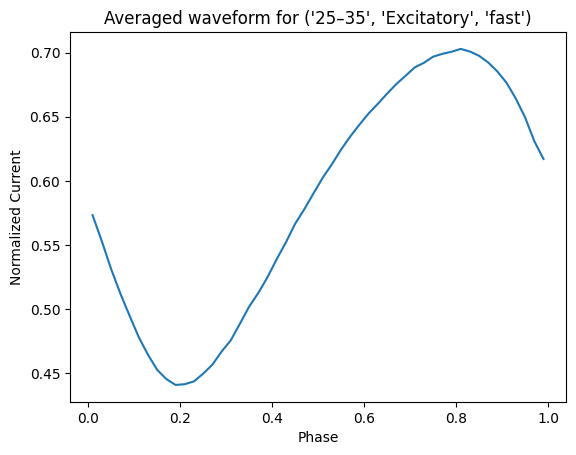

In [ ]:
if avg_waveform_df is not None:
    plt.plot(avg_waveform_df['Phase'], avg_waveform_df['Normalized Current'])
    plt.xlabel('Phase')
    plt.ylabel('Normalized Current')
    plt.title(f'Averaged waveform for {example_key}')
    plt.show()


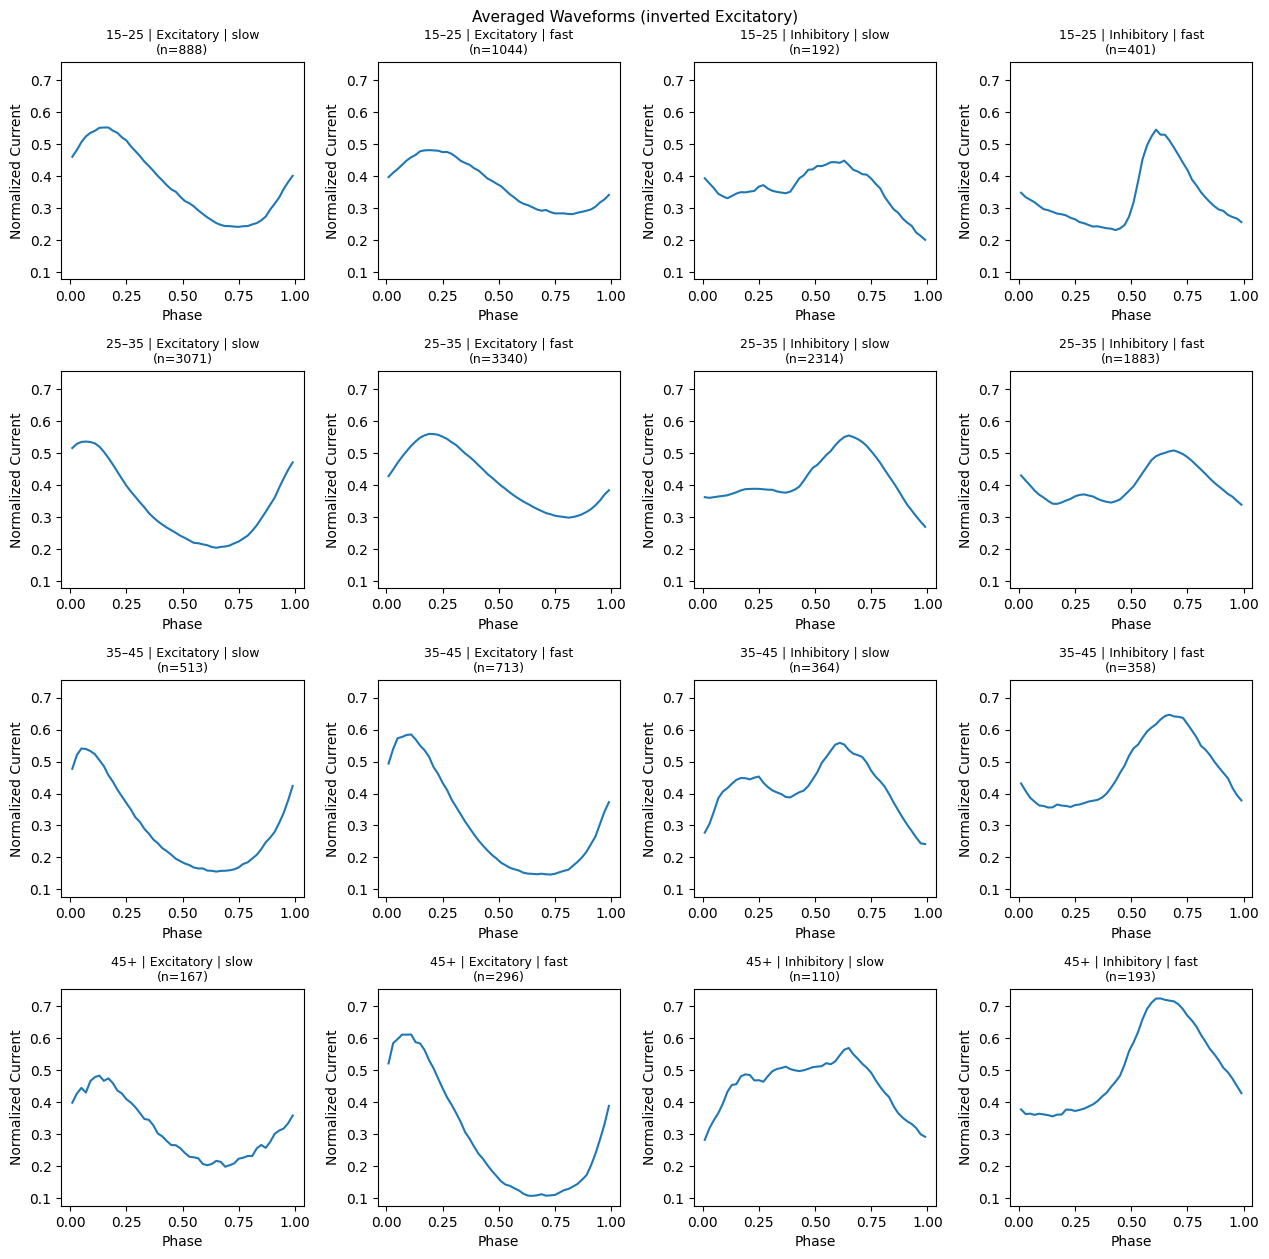

In [ ]:
def average_waveforms_for_key_invert(counter_key):
    """
    Like average_waveforms_for_key, but optionally inverts excitatory signals.
    
    Parameters
    ----------
    counter_key : tuple
        (freq_bin, signal_type, fast_slow)
    invert_excitatory : bool
        If True, flip the sign of excitatory signals.
    value_col : str
        Column to invert (e.g., 'Normalized Current' or 'Current').
    
    Returns
    -------
    DataFrame or None
        Averaged waveform with optional inversion.
    """
    invert_excitatory=True 
    value_col="Normalized Current"
    averaged = average_waveforms_for_key_median(counter_key)
    if averaged is None:
        return None
    
    freq_bin, signal_type, fast_slow = counter_key
    if invert_excitatory and signal_type == "Excitatory":
        if value_col in averaged.columns:
            averaged[value_col] = 1-averaged[value_col]
    return averaged


def plot_counter_grid(
    key_counts,
    value_col="Normalized Current",   # or "Current"
    ncols=5,
    linewidth=1.5,
    sharey=True,
    figsize_per_row=3.2,
    title_fontsize=9,
    suptitle=None
):
    """
    Plot averaged waveforms for every key in `key_counts` (a Counter whose keys are
    (freq_bin, signal_type, fast_slow)) in a grid of subplots.

    Requires a function `average_waveforms_for_key(counter_key)` in scope that returns
    a DataFrame with columns ['Phase', value_col] for the provided key.
    """
    # Sort keys in a consistent, readable order
    freq_order = ["<15", "15–25", "25–35", "35–45", "45+"]
    signal_order = ["Excitatory", "Inhibitory"]
    speed_order = ["slow", "fast"]

    def sort_key(k):
        fb, st, sp = k
        return (
            freq_order.index(fb) if fb in freq_order else len(freq_order),
            signal_order.index(st) if st in signal_order else len(signal_order),
            speed_order.index(sp) if sp in speed_order else len(speed_order),
        )

    keys = sorted(key_counts.keys(), key=sort_key)
    n = len(keys)
    if n == 0:
        print("No keys to plot.")
        return

    # Preload data and compute global y-limits for consistent scaling (optional)
    per_key_data = []
    ymins, ymaxs = [], []
    for k in keys:
        df = average_waveforms_for_key_invert(k)
        per_key_data.append(df)
        if df is not None and value_col in df:
            vals = df[value_col].to_numpy()
            if np.isfinite(vals).any():
                ymins.append(np.nanmin(vals))
                ymaxs.append(np.nanmax(vals))

    global_ylim = None
    if sharey and ymins and ymaxs:
        ypad = 0.05 * (np.nanmax(ymaxs) - np.nanmin(ymins) + 1e-12)
        global_ylim = (np.nanmin(ymins) - ypad, np.nanmax(ymaxs) + ypad)

    # Figure layout
    nrows = math.ceil(n / ncols)
    figsize = (ncols * figsize_per_row, nrows * figsize_per_row)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    # Plot each key
    for ax, k, df in zip(axes, keys, per_key_data):
        fb, st, sp = k
        count = key_counts[k]
        if df is None or df.empty or "Phase" not in df or value_col not in df:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_axis_off()
            continue

        ax.plot(df["Phase"], df[value_col], linewidth=linewidth)
        ax.set_title(f"{fb} | {st} | {sp}\n(n={count})", fontsize=title_fontsize)
        ax.set_xlabel("Phase")
        ax.set_ylabel(value_col)

        if global_ylim is not None:
            ax.set_ylim(global_ylim)

    # Turn off any leftover empty axes (if n doesn't fill the grid)
    for j in range(len(per_key_data), len(axes)):
        axes[j].set_axis_off()

    if suptitle:
        fig.suptitle(suptitle, fontsize=title_fontsize + 2, y=0.98)

    fig.tight_layout()
    plt.show()
plot_counter_grid(key_counts, value_col="Normalized Current", ncols=4, suptitle="Averaged Waveforms (inverted Excitatory)")


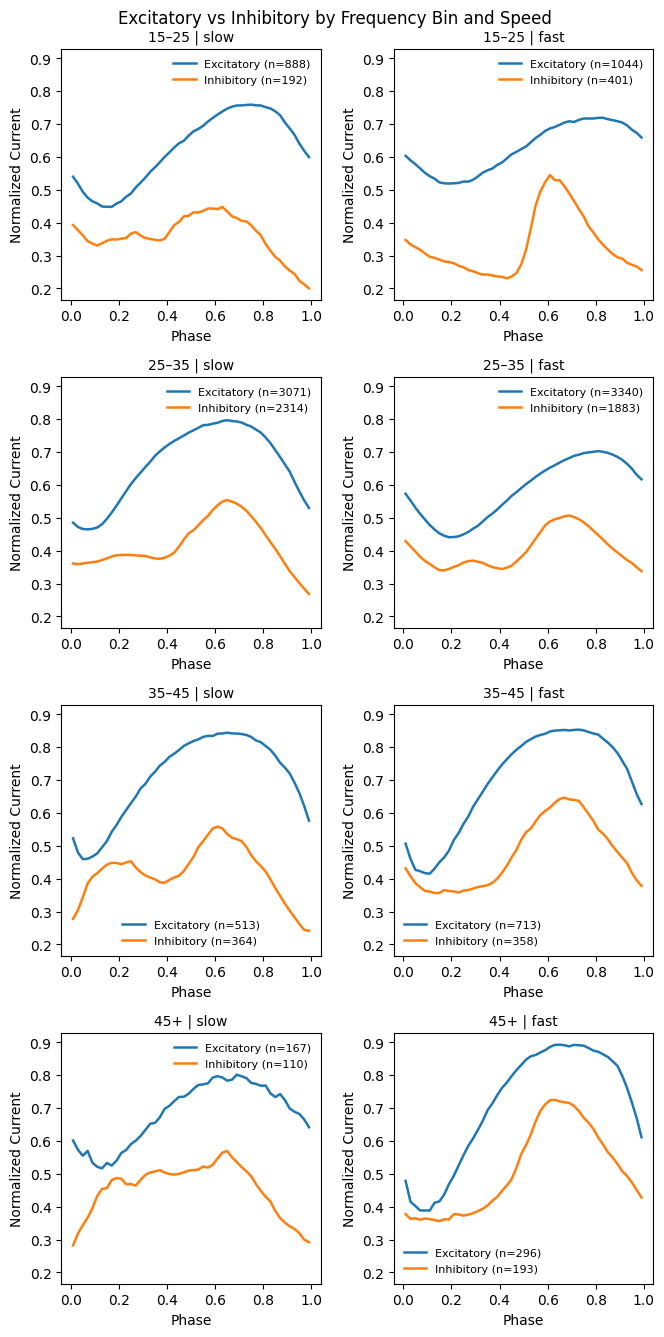

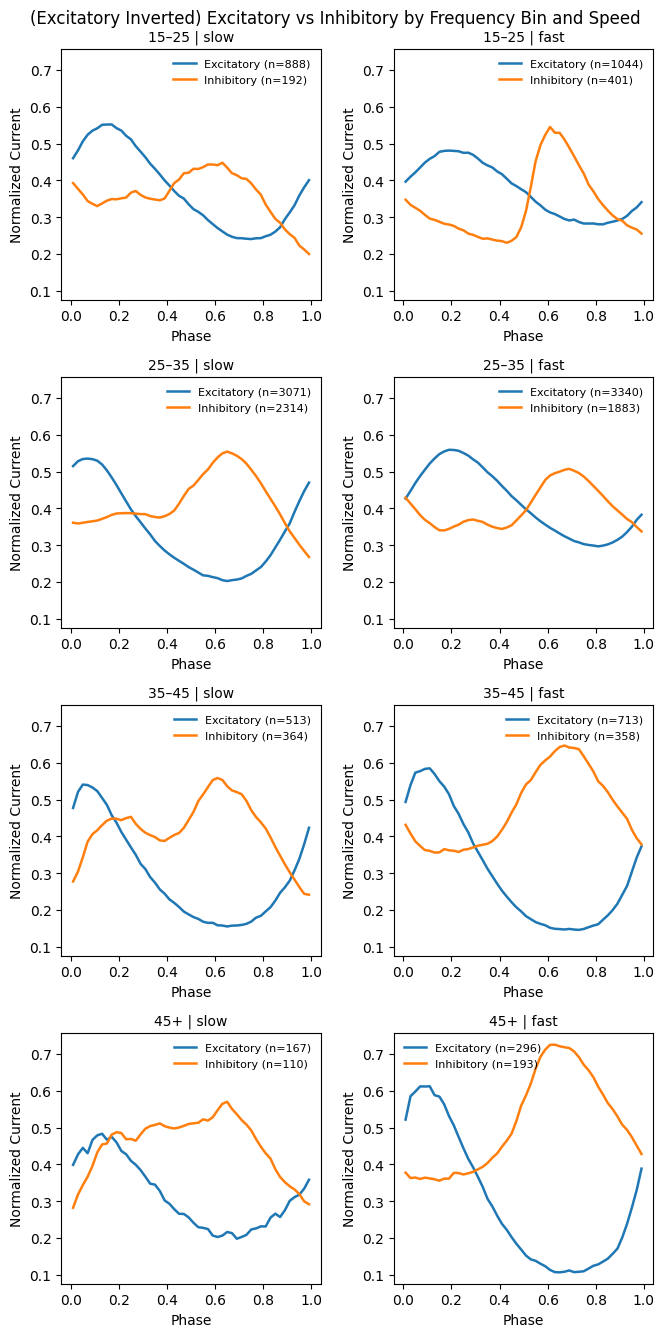

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

def plot_overlay_by_bin_speed(
    key_counts,
    value_col="Normalized Current",   # or "Current"
    invert_excitatory=False,          # flip Excitatory sign if True
    ncols=3,
    linewidth=1.8,
    sharey=True,
    figsize_per_row=3.4,
    title_fontsize=10,
    suptitle=None
):
    """
    Create one subplot per (freq_bin, speed) and overlay Excitatory vs Inhibitory in different colors.

    Requirements:
      - average_waveforms_for_key(counter_key) is defined.
      - If invert_excitatory=True, average_waveforms_for_key_invert(counter_key) is used for Excitatory.
      - key_counts is a Counter keyed by (freq_bin, signal_type, speed) -> count.
    """
    # Sort order for panels
    freq_order = ["<15", "15–25", "25–35", "35–45", "45+"]
    speed_order = ["slow", "fast"]

    # What groups (freq_bin, speed) exist? (require at least one of E/I present)
    groups = set()
    for (fb, st, sp) in key_counts.keys():
        if st in ("Excitatory", "Inhibitory"):
            groups.add((fb, sp))

    if not groups:
        print("No Excitatory/Inhibitory keys found to plot.")
        return

    def sort_group(g):
        fb, sp = g
        return (
            freq_order.index(fb) if fb in freq_order else len(freq_order),
            speed_order.index(sp) if sp in speed_order else len(speed_order),
        )

    groups = sorted(groups, key=sort_group)

    # Helper to fetch averaged df (optionally inverting excitatory)
    def _avg_df(counter_key):
        fb, st, sp = counter_key
        if invert_excitatory and st == "Excitatory":
            return average_waveforms_for_key_invert(counter_key, invert_excitatory=True, value_col=value_col)
        return average_waveforms_for_key_median(counter_key)

    # Preload data & compute global ylim if sharey
    per_group = []
    ymins, ymaxs = [], []
    for fb, sp in groups:
        key_e = (fb, "Excitatory", sp)
        key_i = (fb, "Inhibitory", sp)

        df_e = _avg_df(key_e) if key_e in key_counts else None
        df_i = _avg_df(key_i) if key_i in key_counts else None

        per_group.append(((fb, sp), df_e, df_i))

        for df in (df_e, df_i):
            if df is not None and value_col in df:
                vals = df[value_col].to_numpy()
                if np.isfinite(vals).any():
                    ymins.append(np.nanmin(vals))
                    ymaxs.append(np.nanmax(vals))

    global_ylim = None
    if sharey and ymins and ymaxs:
        pad = 0.05 * (np.nanmax(ymaxs) - np.nanmin(ymins) + 1e-12)
        global_ylim = (np.nanmin(ymins) - pad, np.nanmax(ymaxs) + pad)

    # Layout
    n = len(per_group)
    nrows = math.ceil(n / ncols)
    figsize = (ncols * figsize_per_row, nrows * figsize_per_row)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.ravel()

    # Plot each panel
    for ax, ((fb, sp), df_e, df_i) in zip(axes, per_group):
        # Counts for legend labels
        n_e = key_counts.get((fb, "Excitatory", sp), 0)
        n_i = key_counts.get((fb, "Inhibitory", sp), 0)

        plotted_any = False

        if df_e is not None and not df_e.empty and "Phase" in df_e and value_col in df_e:
            ax.plot(df_e["Phase"], df_e[value_col], linewidth=linewidth, label=f"Excitatory (n={n_e})")
            plotted_any = True

        if df_i is not None and not df_i.empty and "Phase" in df_i and value_col in df_i:
            ax.plot(df_i["Phase"], df_i[value_col], linewidth=linewidth, label=f"Inhibitory (n={n_i})")
            plotted_any = True

        if global_ylim is not None:
            ax.set_ylim(global_ylim)

        ax.axhline(0, lw=0.8, alpha=0.6)
        ax.set_title(f"{fb} | {sp}", fontsize=title_fontsize)
        ax.set_xlabel("Phase")
        ax.set_ylabel(value_col)
        if plotted_any:
            ax.legend(frameon=False, fontsize=8)
        else:
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.set_axis_off()

    # Hide any extra axes
    for j in range(len(per_group), len(axes)):
        axes[j].set_axis_off()

    if suptitle:
        fig.suptitle(suptitle, fontsize=title_fontsize + 2, y=0.98)

    fig.tight_layout()
    plt.show()
# Overlay without inversion
plot_overlay_by_bin_speed(
    key_counts,
    value_col="Normalized Current",
    invert_excitatory=False,
    ncols=2,
    suptitle="Excitatory vs Inhibitory by Frequency Bin and Speed"
)

# Overlay with excitatory inverted
plot_overlay_by_bin_speed(
    key_counts,
    value_col="Normalized Current",
    invert_excitatory=True,
    ncols=2,
    suptitle="(Excitatory Inverted) Excitatory vs Inhibitory by Frequency Bin and Speed"
)


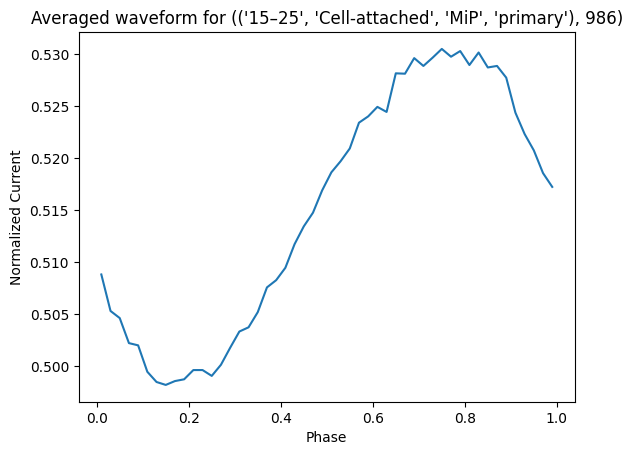

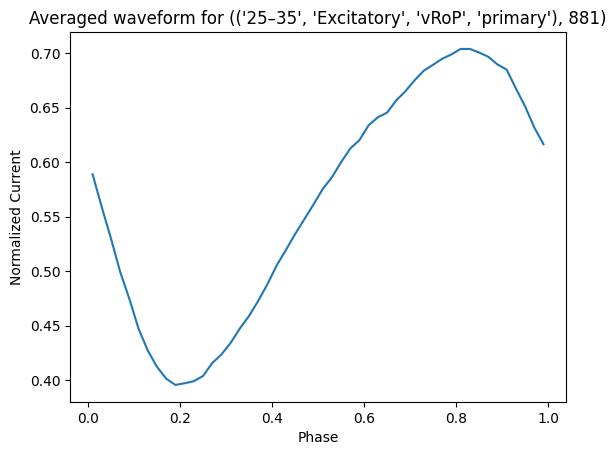

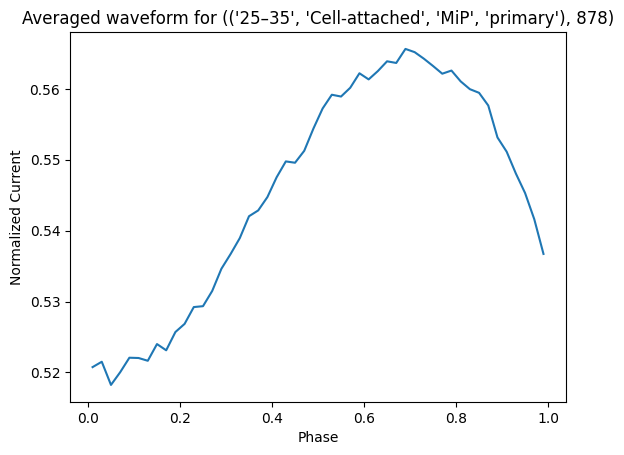

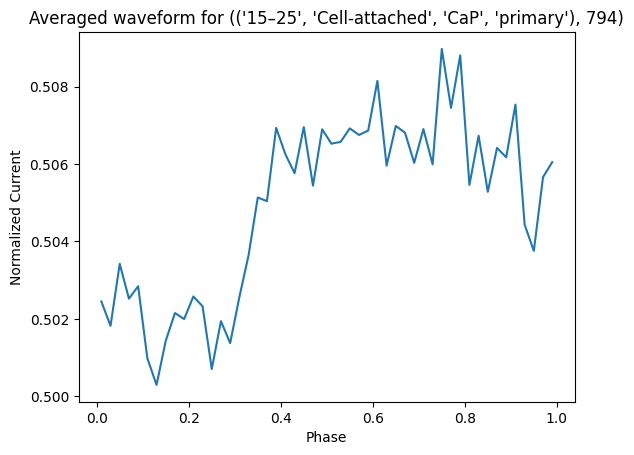

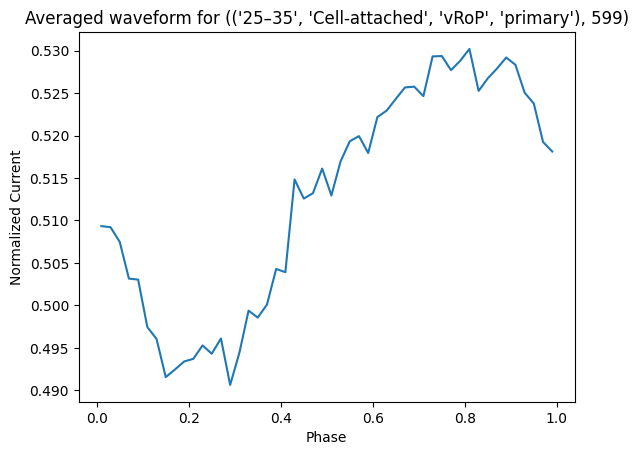

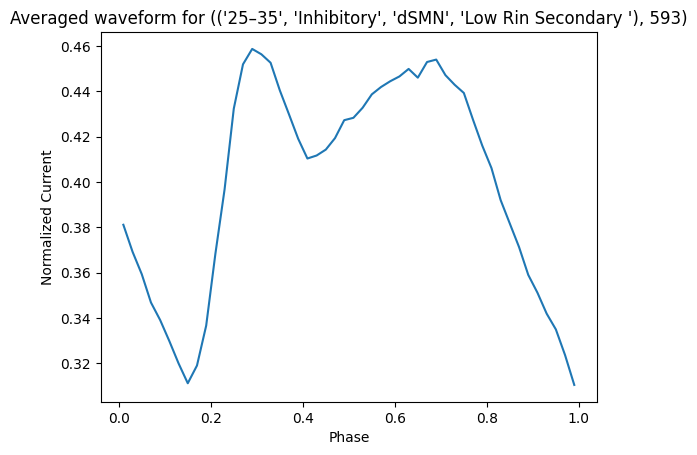

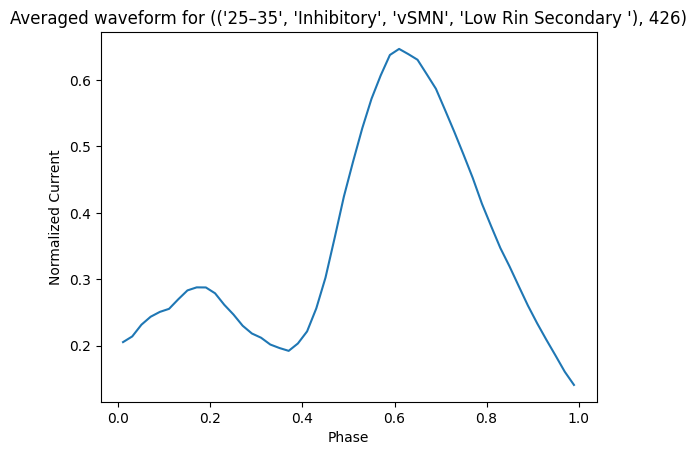

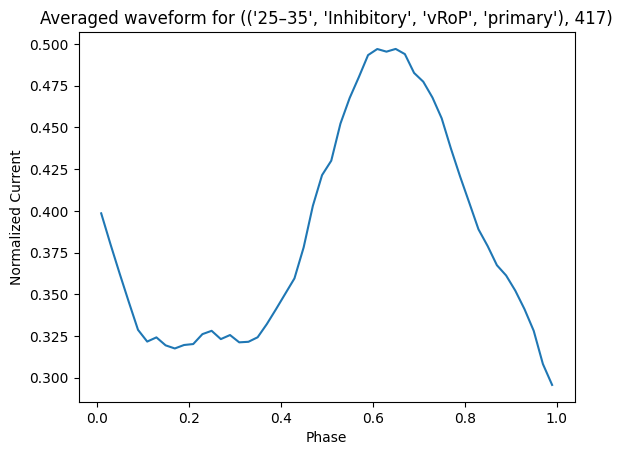

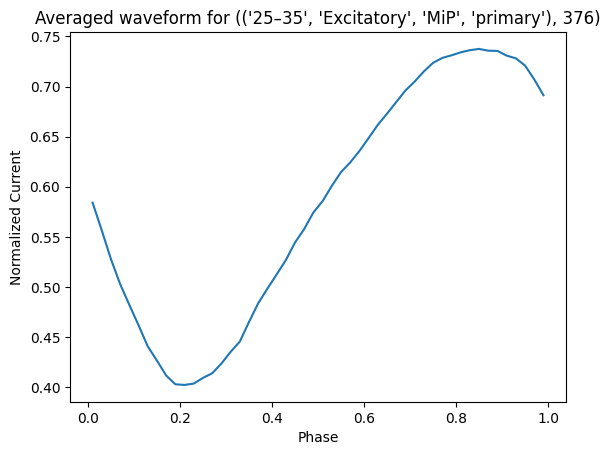

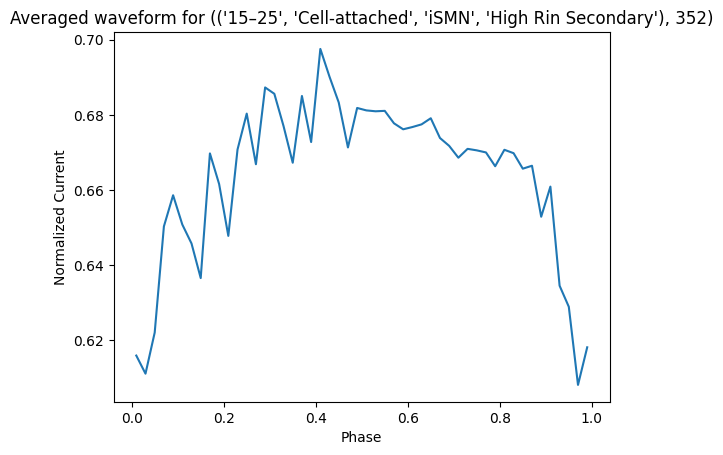

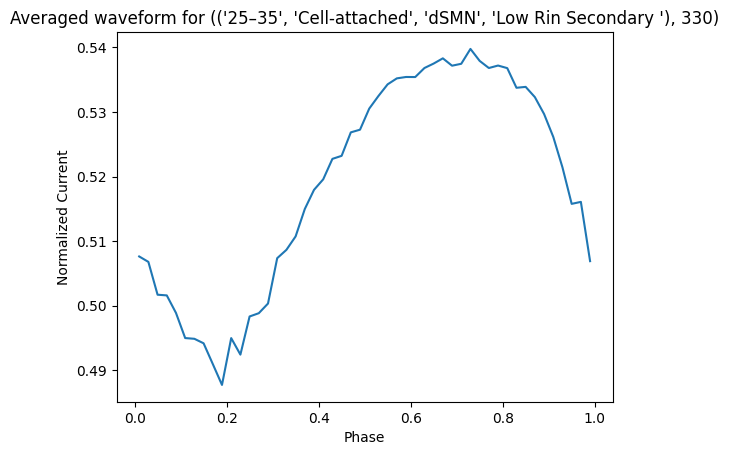

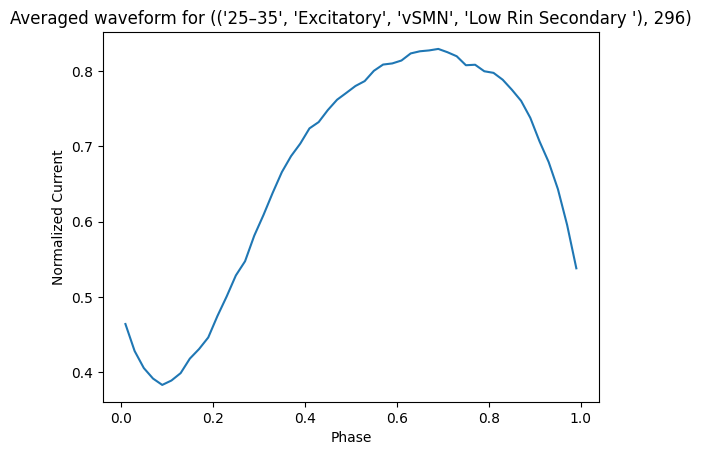

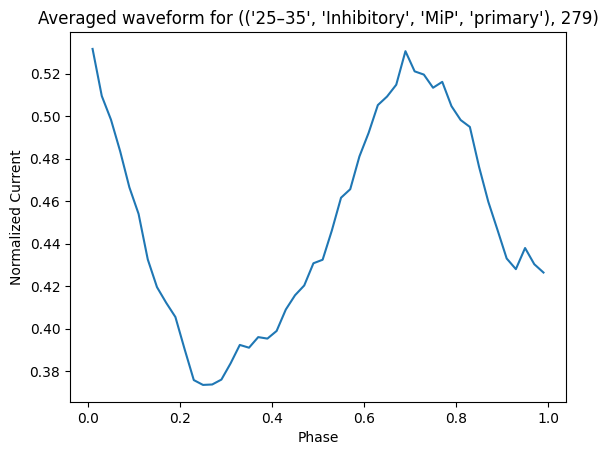

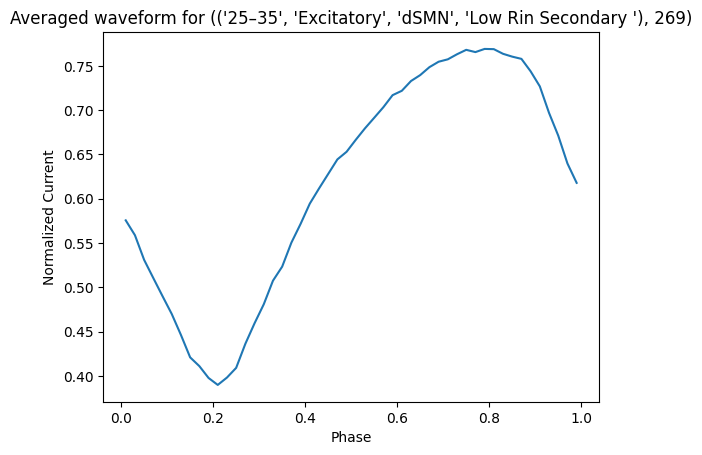

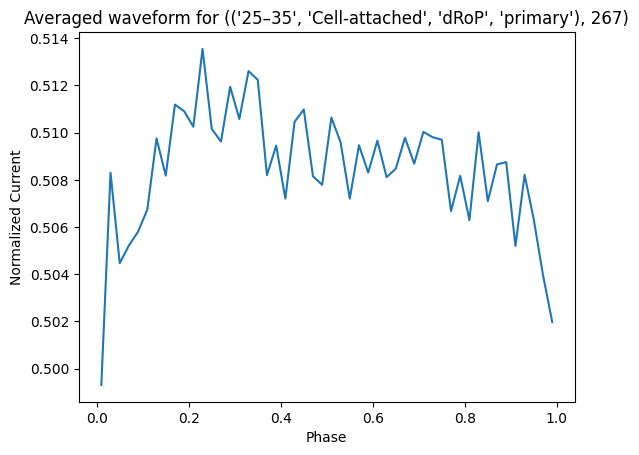

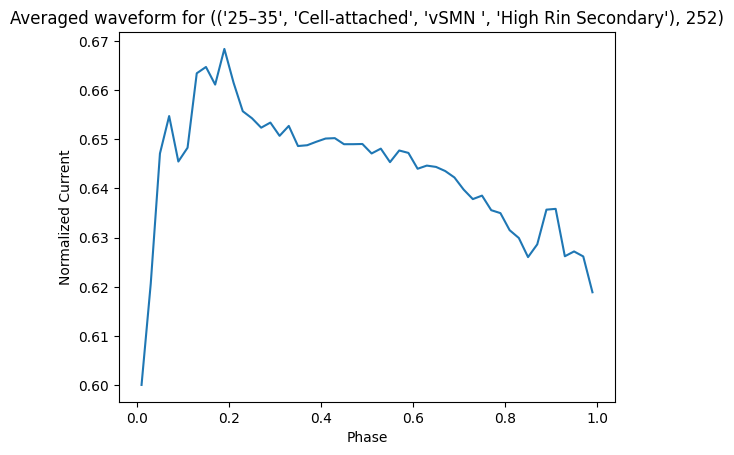

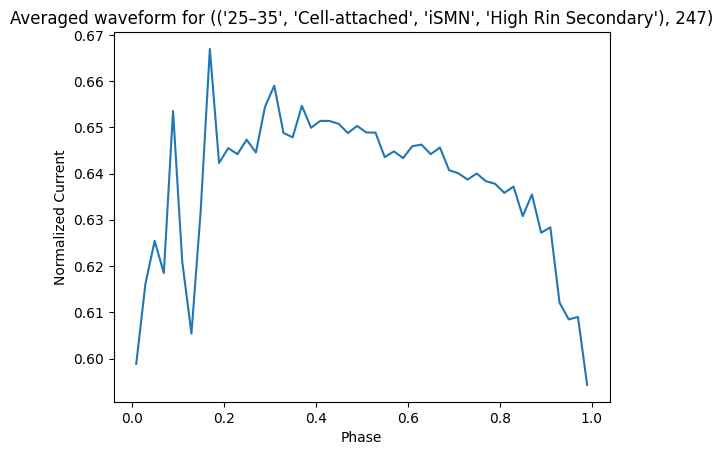

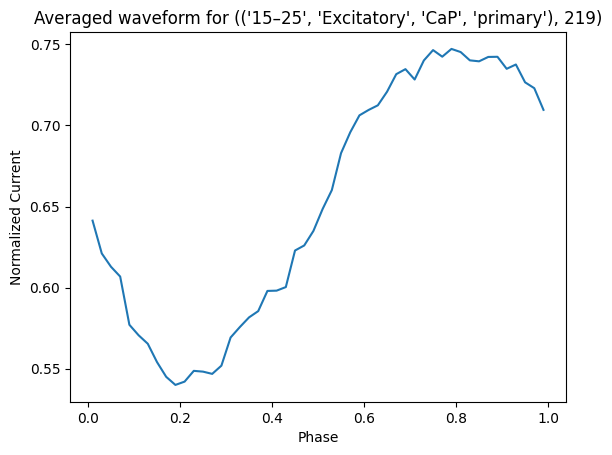

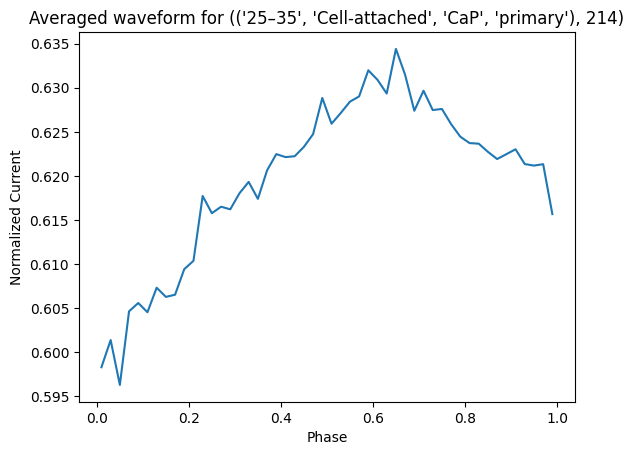

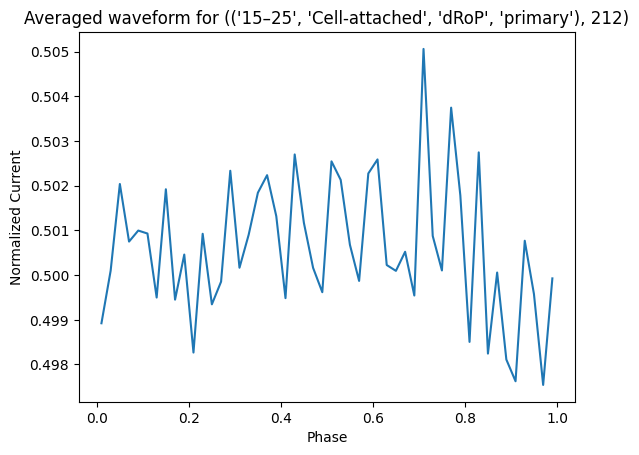

No matching waveforms found for ('25–35', 'Excitatory', 'iSMN', 'High Rin Secondary')


TypeError: 'NoneType' object is not subscriptable

In [ ]:
for key in key_counts.most_common():
    # print(key[0])
    avg_waveform_df = average_waveforms_for_key(key[0])
    plt.plot(avg_waveform_df['Phase'], avg_waveform_df['Normalized Current'])
    plt.xlabel('Phase')
    plt.ylabel('Normalized Current')
    plt.title(f'Averaged waveform for {key}')
    plt.show()